In [140]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import yfinance as yf
import os
import warnings

warnings.filterwarnings("ignore")

In [ ]:
chile_tickers = [
    "ABC.SN", "AGUAS-A.SN", "ALMENDRAL.SN", "ANTARCHILE.SN", "AZUL-AZUL.SN",
    "BANVIDA.SN", "BCI.SN", "BESALCO.SN", "BICE.SN", "BINT.SN", "BLUMAR.SN", "BSANTANDER.SN",
    "CALICHERAA.SN", "CAMANCHACA.SN", "CAMPOS.SN", "CAP.SN", "CAROZZI.SN", "CCU.SN", "CEMENTOS.SN",
    "CENCOMALLS.SN", "CENCOSUD.SN", "CGE.SN", "CGET.SN", "CHILE.SN", "CIC.SN", "CINTAC.SN",
    "CMPC.SN", "COLBUN.SN", "COLO-COLO.SN", "CONCHATORO.SN", "COPEC.SN", "COPEVAL.SN", "CRISTALES.SN",
    "CRUZADOS.SN", "CTC.SN", "CUPRUM.SN", "DUNCANFOX.SN", "ECL.SN", "EISA.SN", "ELECMETAL.SN",
    "EMILIANA.SN", "ENAEX.SN", "ENELAM.SN", "ENELCHILE.SN", "ENELDXCH.SN", "ENELGXCH.SN", "ENJOY.SN",
    "ENLASA.SN", "ENTEL.SN", "ESVAL-C.SN", "FALABELLA.SN", "FORUS.SN", "FOSFOROS.SN", "FROWARD.SN",
    "GASCO.SN", "HABITAT.SN", "HIPERMARC.SN", "HITES.SN", "IAM.SN",
    "IANSA.SN", "ILC.SN", "INDISA.SN", "INFODEMA.SN", "INGEVEC.SN", "INVERCAP.SN", "INVERNOVA.SN",
    "ITAUCL.SN", "LAS-CONDES.SN", "LIPIGAS.SN", "MALLPLAZA.SN", "MANQUEHUE.SN", "MARINSA.SN",
    "MASISA.SN", "MELON.SN", "MINERA.SN", "MOLLER.SN", "MOLYMET.SN", "MULTI-X.SN", "NAVARINO.SN",
    "NAVIERA.SN", "NIBSA.SN", "NITRATOS.SN", "NORTEGRAN.SN", "NTGCLGAS.SN", "NUAM.SN", "NUTRAVALOR.SN",
    "ORO-BLANCO.SN", "OXIQUIM.SN", "PARAUCO.SN", "PASUR.SN", "PAZ.SN", "PEHUENCHE.SN", "PLANVITAL.SN",
    "POLO.SN", "POLPAICO.SN", "POTASIOS-A.SN", "PROVIDA.SN", "QUINENCO.SN", "RIPLEY.SN", "SALFACORP.SN",
    "SALMOCAM.SN", "SCHWAGER.SN", "SCOTIABKCL.SN", "SIEMEL.SN", "SK.SN", "SMSAAM.SN", "SMU.SN",
    "SOCOVESA.SN", "SONDA.SN", "SOQUICOM.SN", "SQM", "TRICAHUE.SN", "TRICOT.SN", "VAPORES.SN",
    "VENTANAS.SN", "VOLCAN.SN", "VSPT.SN", "WATTS.SN", "ZOFRI.SN", "CLP=X", "^IPSA"
]

In [ ]:
data_20y = yf.download(
    tickers=" ".join(chile_tickers),
    period="20y",  # Periodo de 20 años
    interval="1d", # Intervalo diario (el más granular para este periodo)
    group_by='ticker' # Organiza los datos por ticker en el DataFrame
)

data_20y.columns = data_20y.columns.map('_'.join)

data_20y.to_csv(os.path.join("..", "data", "chile-stocks-raw.csv"))

' data_20y = yf.download(\n    tickers=" ".join(chile_tickers),\n    period="20y",  # Periodo de 20 años\n    interval="1d", # Intervalo diario (el más granular para este periodo)\n    group_by=\'ticker\' # Organiza los datos por ticker en el DataFrame\n)\n\ndata_20y.columns = data_20y.columns.map(\'_\'.join)\n\ndata_20y.to_csv(os.path.join("..", "data", "chile-stocks.csv")) '

In [ ]:
data_20y = pd.read_csv(os.path.join("..", "data", "chile-stocks-raw.csv"))
data_20y["Date"] = pd.to_datetime(data_20y["Date"])
data_20y = data_20y.set_index("Date")
data_20y = data_20y[data_20y.any().index]

# Data cleaning

## Azul azul

<Axes: xlabel='Date'>

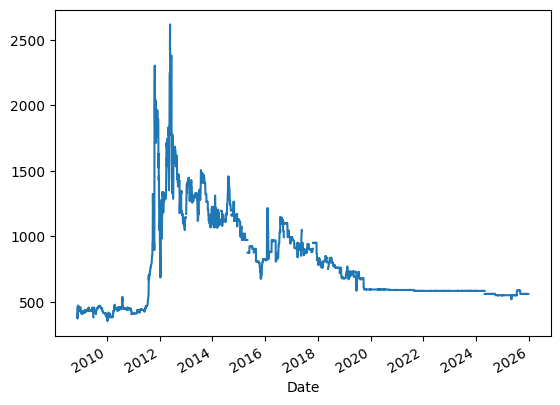

In [228]:
data_20y["AZUL-AZUL.SN_Close"][data_20y["AZUL-AZUL.SN_Close"] < 1] = None
#data_20y["AZUL-AZUL.SN_Close"] = data_20y["AZUL-AZUL.SN_Close"].ffill()
data_20y["AZUL-AZUL.SN_Close"].plot()

## Camanchaca

<Axes: xlabel='Date'>

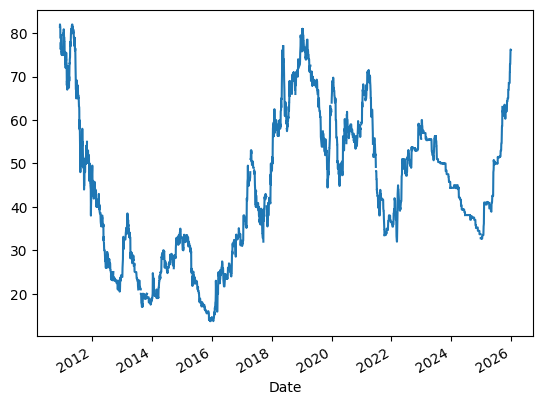

In [229]:
data_20y.loc[ data_20y["CAMANCHACA.SN_Close"] > 1000, "CAMANCHACA.SN_Close"] = None
data_20y["CAMANCHACA.SN_Close"].plot()

## BSantander

<Axes: xlabel='Date'>

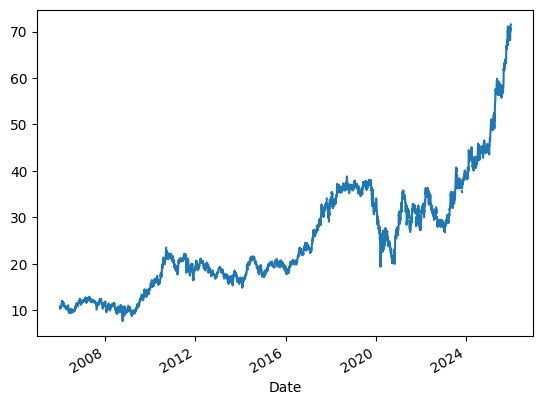

In [230]:
data_20y.loc[ data_20y["BSANTANDER.SN_Close"] > 250, "BSANTANDER.SN_Close"] = None
data_20y["BSANTANDER.SN_Close"].plot()

## ENJOY

<Axes: xlabel='Date'>

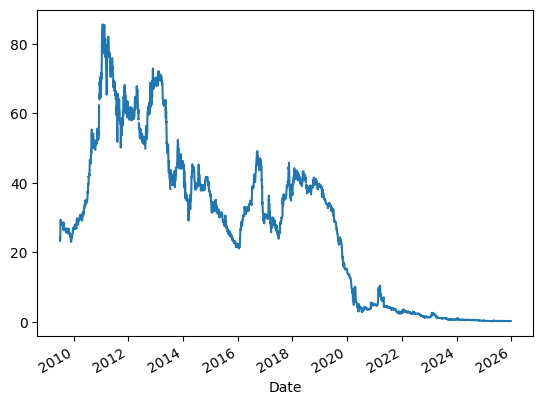

In [231]:
data_20y.loc[ ("2009-06-01" < data_20y.index) & ("2009-08-01" > data_20y.index) & (data_20y["ENJOY.SN_Close"] < 2), "ENJOY.SN_Close"] = None 
data_20y["ENJOY.SN_Close"].plot()

## ENLASA

<Axes: xlabel='Date'>

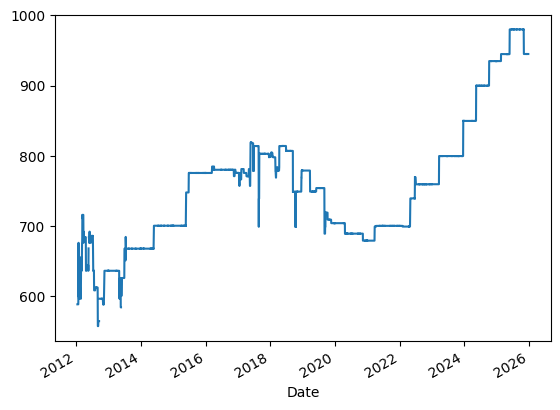

In [232]:
data_20y.loc[ ("2011-12-29" < data_20y.index) & ("2012-01-13" > data_20y.index), "ENLASA.SN_Close"] = None 
data_20y["ENLASA.SN_Close"].plot()

## QUINENCO

<Axes: xlabel='Date'>

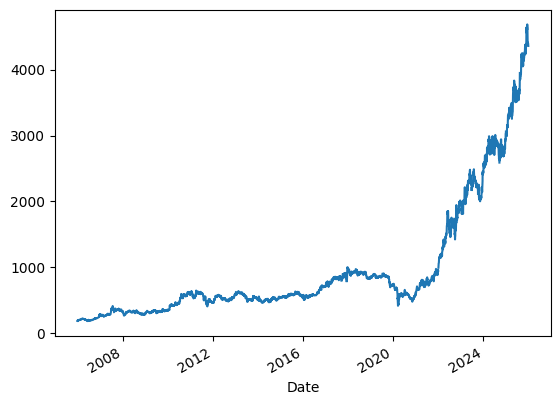

In [233]:
data_20y.loc[ data_20y["QUINENCO.SN_Close"] > 10_000, "QUINENCO.SN_Close"] = None 
data_20y["QUINENCO.SN_Close"].plot()

## ZOFRI 

<Axes: xlabel='Date'>

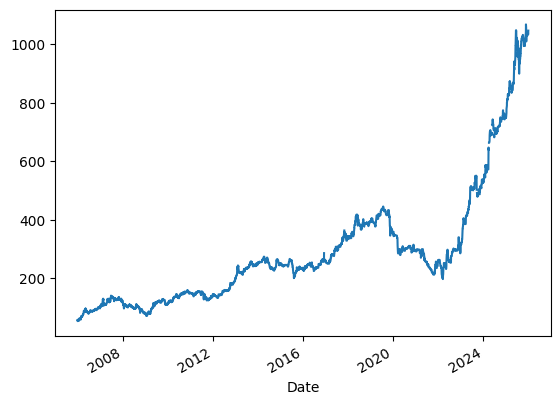

In [234]:
data_20y.loc[ (data_20y.index > "2011-06-01") & (data_20y.index < "2012") & ( data_20y["ZOFRI.SN_Close"] < 100) ,"ZOFRI.SN_Close"] = None 
data_20y["ZOFRI.SN_Close"].plot()

## NUAM 

<Axes: xlabel='Date'>

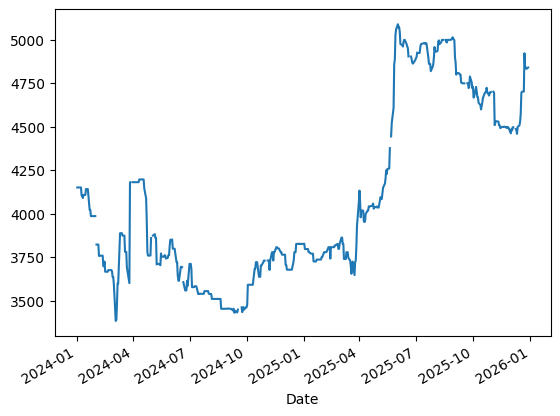

In [250]:
data_20y.loc[ (data_20y.index > "2023-10") & (data_20y.index < "2024-01")  ,"NUAM.SN_Close"] = None 
data_20y["NUAM.SN_Close"].plot()

## CLP USD

In [ ]:
data_20y.loc[ (data_20y.index > "2023-10") & (data_20y.index < "2024-01")  ,"NUAM.SN_Close"]

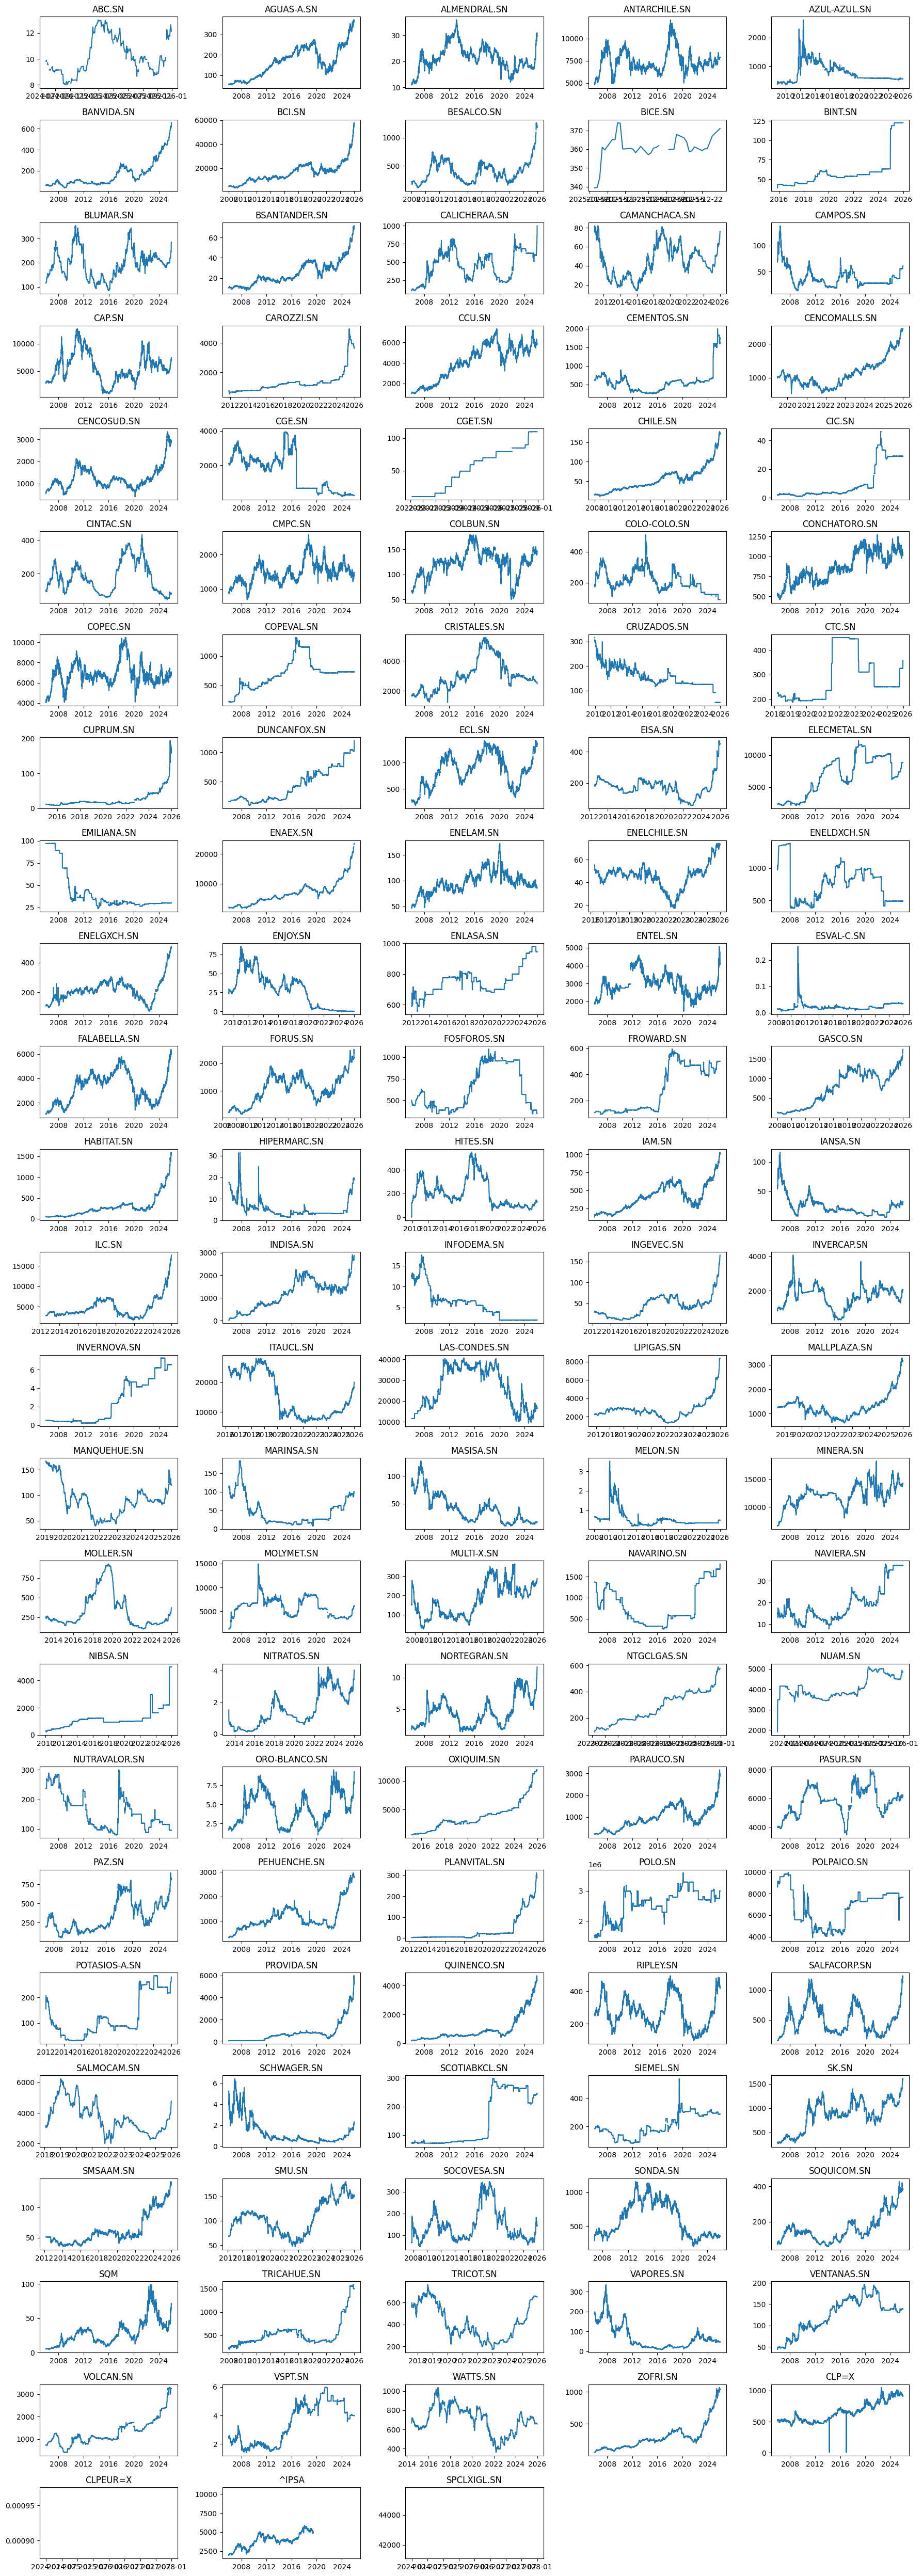

In [235]:
plt.figure(figsize = (18, 50))

for i, ticker in enumerate(chile_tickers):
    
    ax = plt.subplot(25, 5, i + 1)
    plt.title(ticker)
    ax.plot( (data_20y[ticker + "_Close"]))

plt.tight_layout()
plt.show()

In [132]:
df = data_20y[list(filter( lambda x: "Close" in x, data_20y.columns))]

C:\Users\Marti\AppData\Local\Temp\ipykernel_27240\3157944599.py:1: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df = df.pct_change().fillna(0)


<Axes: xlabel='Date'>

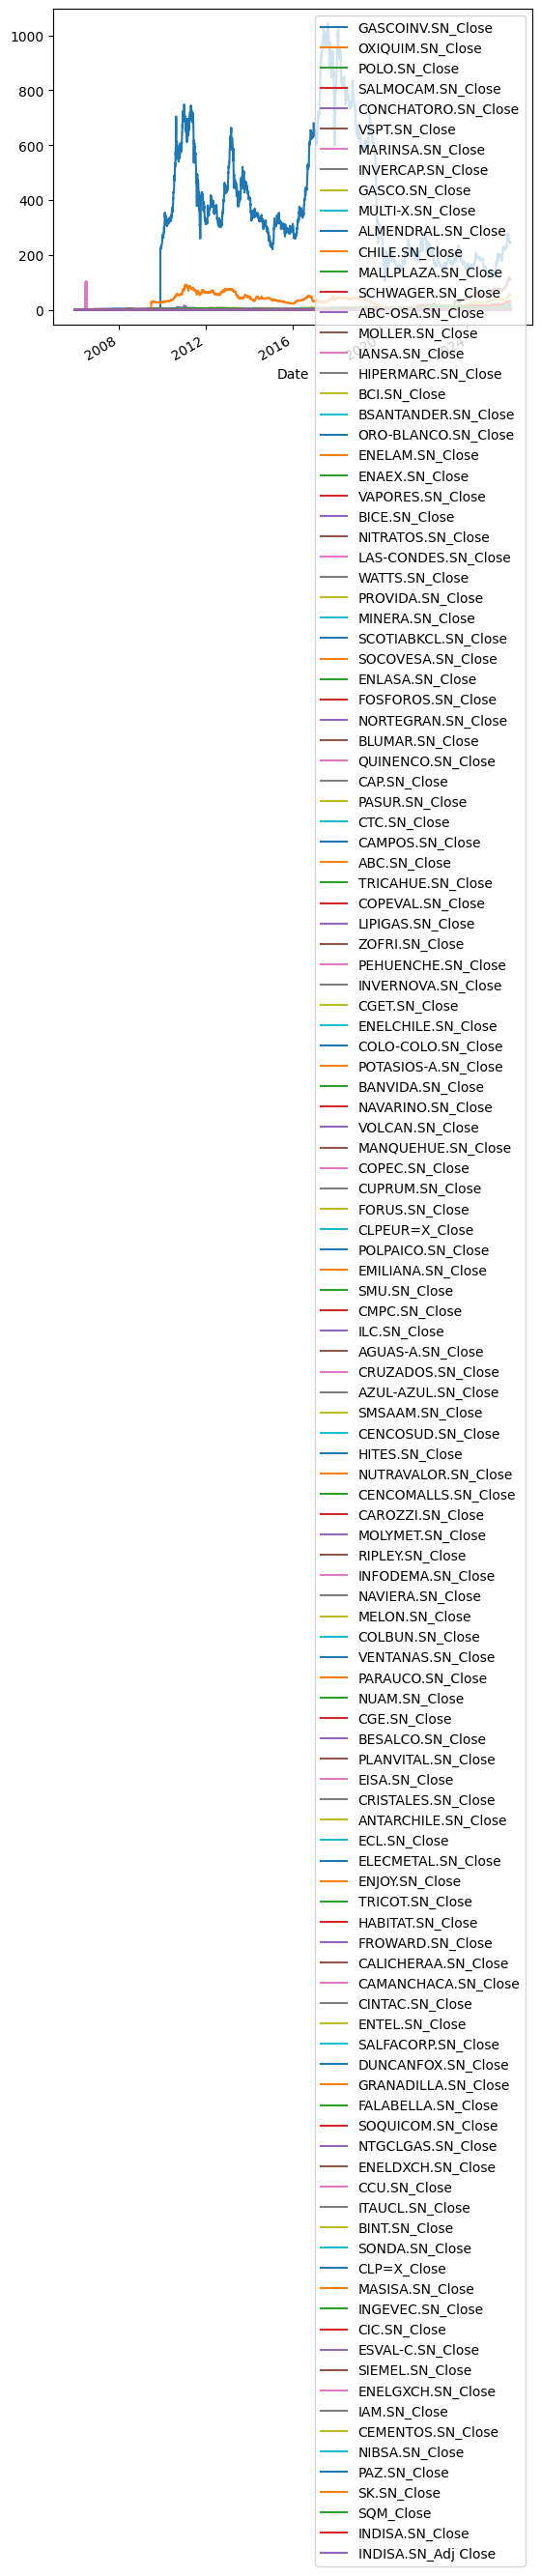

In [133]:
df = df.pct_change().fillna(0)
(df + 1).cumprod().plot()

In [88]:
# Find which columns meet the condition (cumulative product > 50000)
df = data_20y[list(filter( lambda x: "Close" in x, data_20y.columns))]
df = df.pct_change().fillna(0)

# Check which columns exceed 50000
condition_result = (df + 1).cumprod() > 50000
columns_meeting_condition = condition_result.columns[condition_result.any()].tolist()

print("Columns where cumulative return exceeds 50000x:")
print(columns_meeting_condition)
print(f"\nTotal columns meeting condition: {len(columns_meeting_condition)}")

Columns where cumulative return exceeds 50000x:
['AZUL-AZUL.SN_Close']

Total columns meeting condition: 1


C:\Users\Marti\AppData\Local\Temp\ipykernel_27240\548261151.py:3: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df = df.pct_change().fillna(0)
